### Setup

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import scipy.io
import matplotlib.gridspec as gridspec
import os

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

[device] cuda


In [15]:
pval           = 0.05
beta           = 1
epochs         = 4
batch_size     = 1
bottleneck_dim = 25
lr             = 1e-3

### Dataset

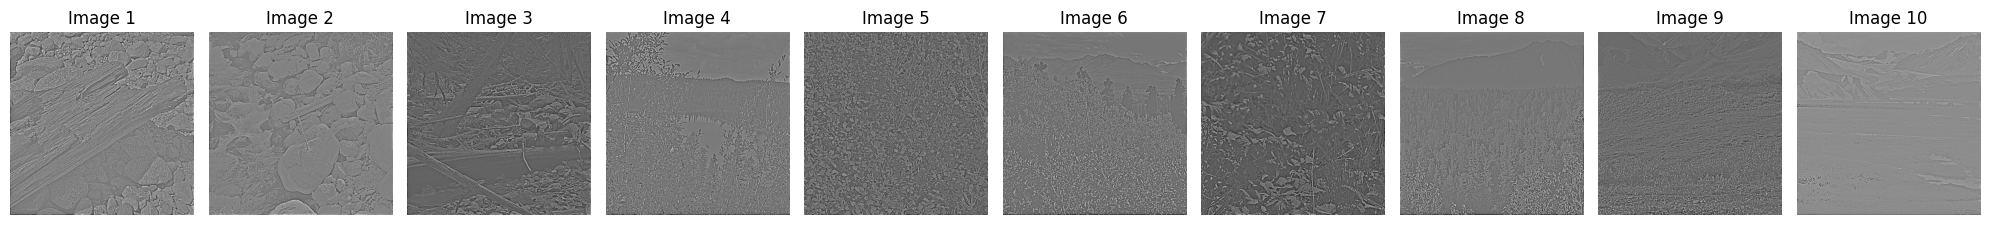

In [16]:
# IMAGES.mat was taken from Andrew Ng's course, which is also where we're getting notes for the Sparse Autoencoder
# Obtained here: https://github.com/fanfeng2015
mat           = scipy.io.loadmat('IMAGES.mat')
wh_landscapes = torch.Tensor(mat['IMAGES']).permute(2, 0, 1) # Shape: (num_images, height, width)

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(wh_landscapes[i, :, :].cpu(), cmap='gray')
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
class AndrewNgLandscape(Dataset):
    def __init__(self, wh_landscapes):
        self.wh_landscapes = wh_landscapes
        self.num_samples = 10000
        self.patch_size = 8
        self.image_height = wh_landscapes.shape[1]
        self.image_width = wh_landscapes.shape[2]

        self.grid_h = self.image_height // self.patch_size
        self.grid_w = self.image_width // self.patch_size

        self.patches = []
        for _ in range(self.num_samples):
            image_idx = torch.randint(0, self.wh_landscapes.shape[0], (1,)).item()
            grid_x = torch.randint(0, self.grid_h, (1,)).item()
            grid_y = torch.randint(0, self.grid_w, (1,)).item()

            x_start = grid_x * self.patch_size
            y_start = grid_y * self.patch_size

            patch = self.wh_landscapes[
                image_idx,
                x_start : x_start + self.patch_size,
                y_start : y_start + self.patch_size,
            ]
            self.patches.append(patch.flatten())

        self.patches = torch.stack(self.patches)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.patches[idx]

In [18]:
landscape_dataset = AndrewNgLandscape(wh_landscapes)
data_loader       = DataLoader(landscape_dataset, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count() // 2, pin_memory=True)

### Autoencoders

In [19]:
class Autoencoder(nn.Module):
    def __init__(
        self,
        dim: tuple
    ) -> None:
        super().__init__()

        input_dim, bottleneck_dim = dim

        self.encoder = nn.Linear(input_dim, bottleneck_dim)
        self.sigmoid = nn.Sigmoid()
        self.decoder = nn.Linear(bottleneck_dim, input_dim)

    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:
        if x.ndim == 1:
            x = x.unsqueeze(0)
        z = self.encoder(x)
        a = self.sigmoid(z)
        z_recon = self.decoder(a)

        return z_recon, a.mean(dim=0)

In [20]:
class SparseMSELoss(nn.Module):
    def __init__(
        self,
        beta: float = 1.0
    ) -> None:
        super().__init__()
        self.mse_loss = nn.MSELoss()
        self.beta = beta

    def forward(
        self,
        x_recon: torch.Tensor,
        x_original: torch.Tensor,
        p: torch.Tensor,
        p_hat: torch.Tensor,
    ) -> torch.Tensor:
        mse_loss = self.mse_loss(x_recon, x_original)

        p     = torch.clamp(p,     min=1e-7, max=1 - 1e-7)
        p_hat = torch.clamp(p_hat, min=1e-7, max=1 - 1e-7)

        kl_divergence = torch.sum(
            p       * (torch.log(p)     - torch.log(p_hat)) +
            (1 - p) * (torch.log(1 - p) - torch.log(1 - p_hat))
        )

        total_loss = mse_loss + self.beta * kl_divergence
        return total_loss

In [21]:
normal_autoencoder = Autoencoder(dim=(64, bottleneck_dim)).to(device)
normal_criterion   = nn.MSELoss()
normal_optimizer   = torch.optim.SGD(normal_autoencoder.parameters(), lr=lr, momentum=True)

sparse_autoencoder = Autoencoder(dim=(64, bottleneck_dim)).to(device)
sparse_criterion   = SparseMSELoss(beta=beta)
sparse_optimizer   = torch.optim.SGD(sparse_autoencoder.parameters(), lr=lr, momentum=True)

### Training

In [22]:
normal_losses = []
sparse_losses = []

normal_autoencoder.train()
sparse_autoencoder.train()
epochbar = tqdm(range(1, epochs + 1), desc="Epochs")

p = torch.tensor(pval)
for epoch in epochbar:
    normal_epoch_loss = 0.0
    sparse_epoch_loss = 0.0
    for batch_inputs in data_loader:
        batch_input = batch_inputs.to(device)
        normal_optimizer.zero_grad()
        sparse_optimizer.zero_grad()

        normal_x_recon, _     = normal_autoencoder(batch_input)
        sparse_x_recon, p_hat = sparse_autoencoder(batch_input)

        normal_loss = normal_criterion(normal_x_recon, batch_input)
        sparse_loss = sparse_criterion(sparse_x_recon, batch_input, p, p_hat)

        normal_loss.backward()
        sparse_loss.backward()

        normal_optimizer.step()
        sparse_optimizer.step()

        normal_batch_loss = normal_loss.item()
        sparse_batch_loss = sparse_loss.item()

        normal_epoch_loss += normal_batch_loss * batch_inputs.size(0)
        sparse_epoch_loss += sparse_batch_loss * batch_inputs.size(0)

        epochbar.set_postfix({
            "normal_loss": f"{normal_batch_loss:.4f}",
            "sparse_loss": f"{sparse_batch_loss:.4f}"
        })

    normal_epoch_loss /= len(data_loader.dataset)
    sparse_epoch_loss /= len(data_loader.dataset)

    normal_losses.append(normal_epoch_loss)
    sparse_losses.append(sparse_epoch_loss)

Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

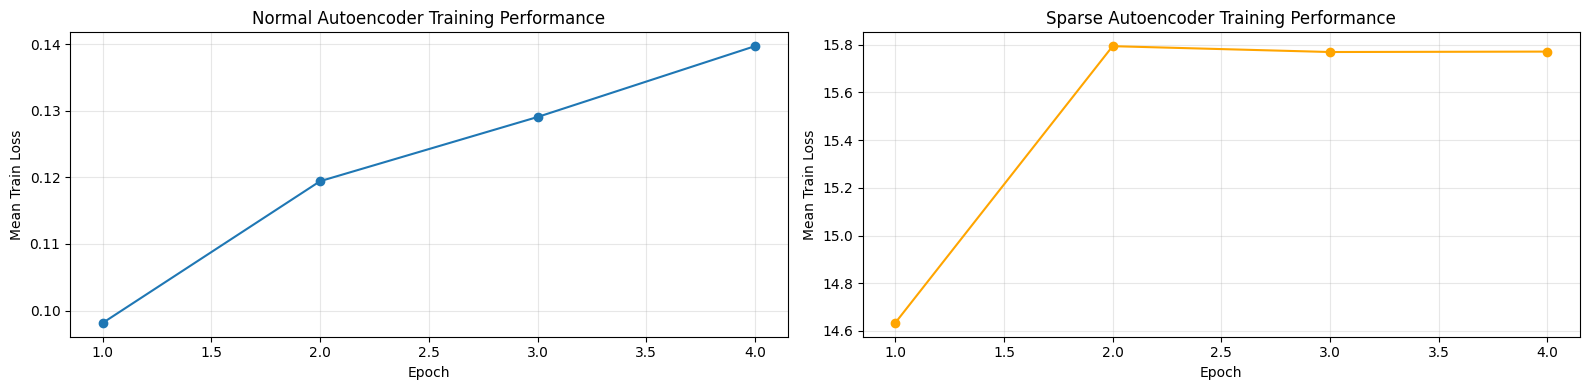

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(range(1, epochs + 1), normal_losses, "o-")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Train Loss")
axes[0].set_title("Normal Autoencoder Training Performance")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), sparse_losses, "o-", color='orange')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Train Loss")
axes[1].set_title("Sparse Autoencoder Training Performance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization

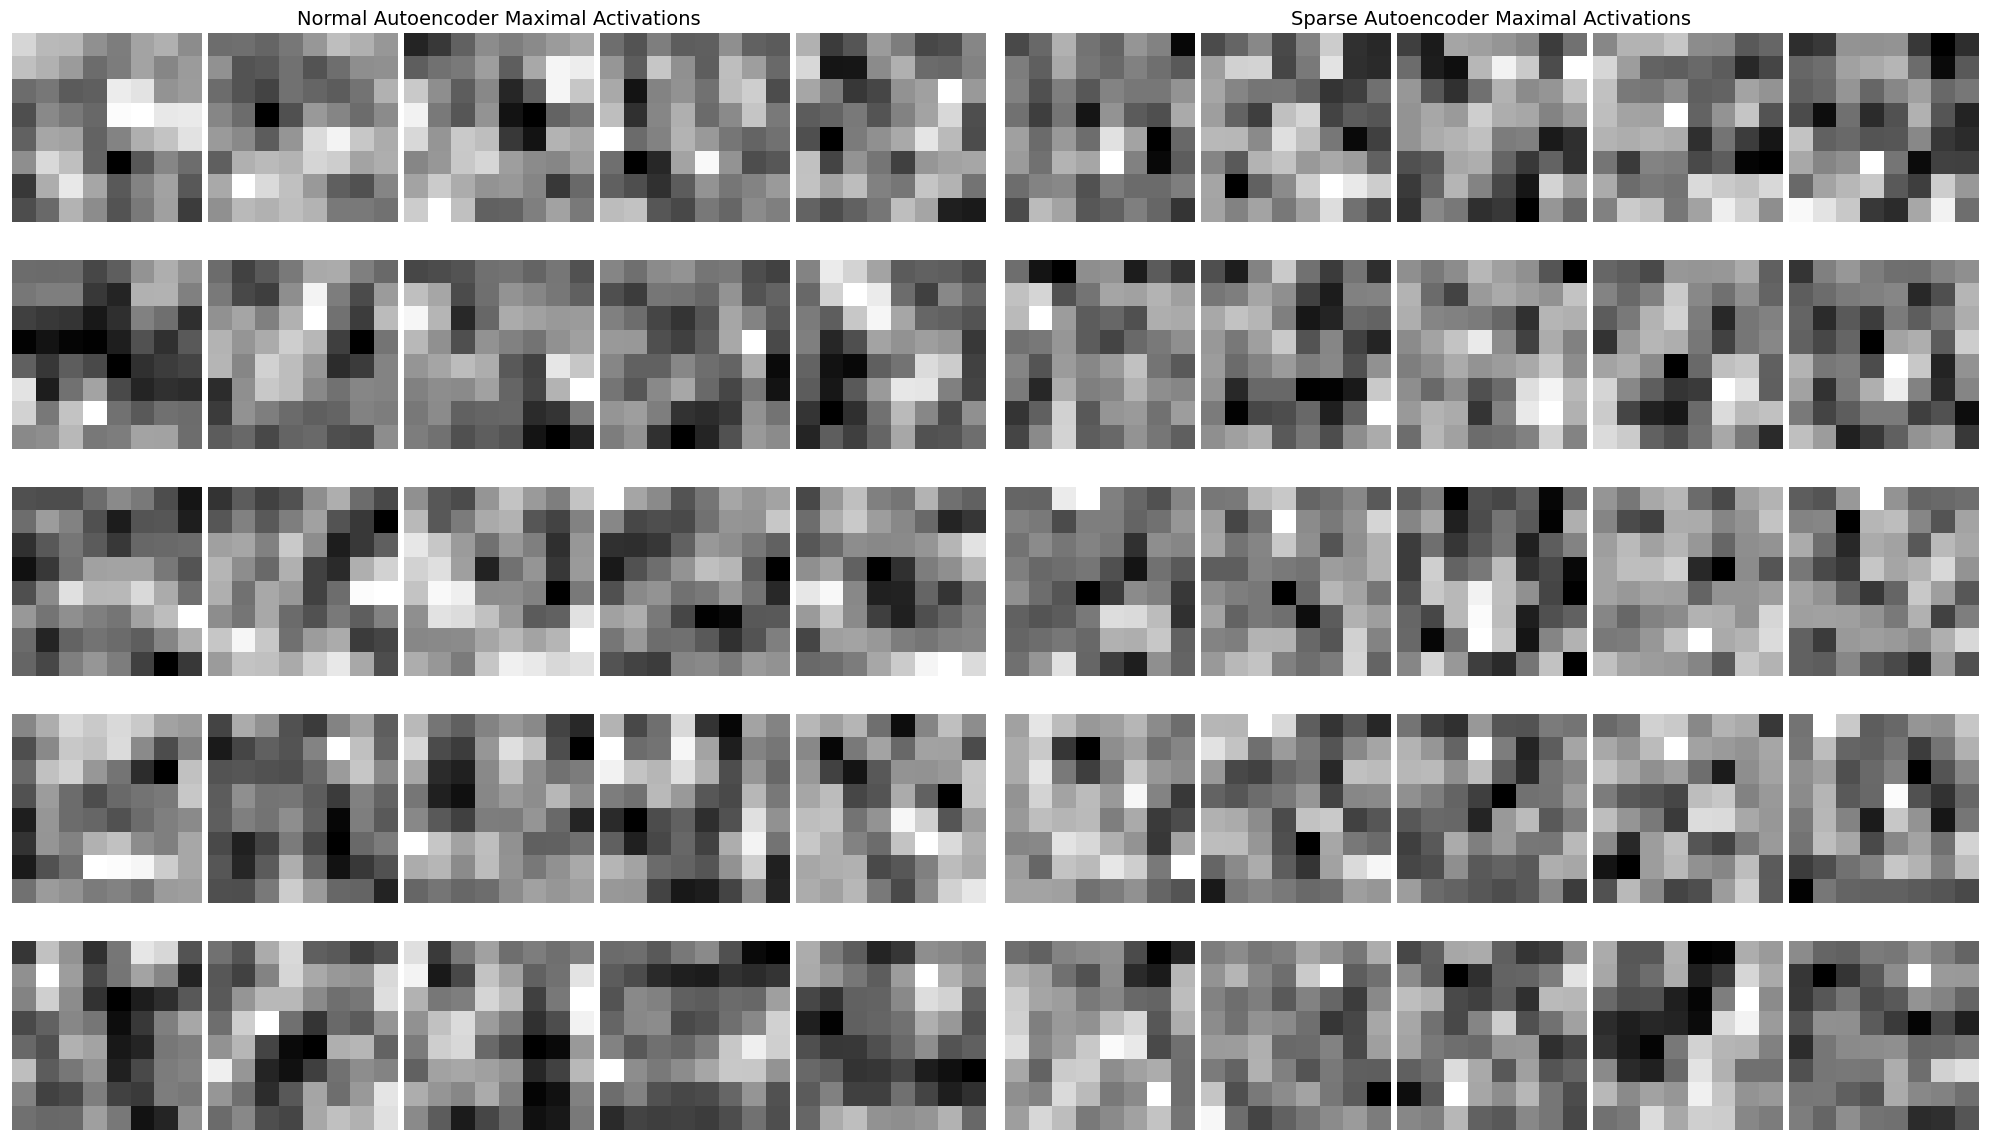

In [24]:
W_enc_normal = normal_autoencoder.encoder.weight.detach().cpu()
normalized_features_normal = W_enc_normal / (W_enc_normal**2).sum(dim=0, keepdim=True).clamp(min=1e-8)

W_enc_sparse = sparse_autoencoder.encoder.weight.detach().cpu()
normalized_features_sparse = W_enc_sparse / (W_enc_sparse**2).sum(dim=0, keepdim=True).clamp(min=1e-8)

num_cols = 5
num_rows = (bottleneck_dim + num_cols - 1) // num_cols

fig = plt.figure(figsize=(num_cols * 4, num_rows * 2.5))
gs_main = gridspec.GridSpec(1, 2, figure=fig)

ax_normal_main = fig.add_subplot(gs_main[0, 0])
ax_normal_main.set_title('Normal Autoencoder Maximal Activations', fontsize=14)
ax_normal_main.axis('off')

gs_normal_sub = gridspec.GridSpecFromSubplotSpec(num_rows, num_cols, subplot_spec=gs_main[0, 0])

for j in range(bottleneck_dim):
    ax = fig.add_subplot(gs_normal_sub[j // num_cols, j % num_cols])
    feature_patch = normalized_features_normal[j, :].reshape(8, 8)
    ax.imshow(feature_patch, cmap='gray')
    ax.axis('off')

ax_sparse_main = fig.add_subplot(gs_main[0, 1])
ax_sparse_main.set_title('Sparse Autoencoder Maximal Activations', fontsize=14)
ax_sparse_main.axis('off')

gs_sparse_sub = gridspec.GridSpecFromSubplotSpec(num_rows, num_cols, subplot_spec=gs_main[0, 1])

for j in range(bottleneck_dim):
    ax = fig.add_subplot(gs_sparse_sub[j // num_cols, j % num_cols])
    feature_patch = normalized_features_sparse[j, :].reshape(8, 8)
    ax.imshow(feature_patch, cmap='gray')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()